<a href="https://www.kaggle.com/code/kareembasemgoda/global-e-commerce-analysis?scriptVersionId=306778847" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# **Overview**

This notebook performs a full exploratory data analysis (EDA) on a global e-commerce dataset with 1M+ records covering orders from 2024–2026. The analysis is structured into 3 main sections: reading the data, exploring it, and Data Visualizations and Insights.

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# **Read Data**

In [2]:
df=pd.read_csv("/kaggle/input/datasets/akrambelha/global-e-commerce-dataset-1m-records-20242026/ecommerce_dataset_+1m.csv")

In [3]:
df.shape

(1000123, 62)

In [4]:
df.head()

,order_id,order_date,order_year,order_month,order_day,order_hour,order_minute,order_second,is_weekend,order_status,...,campaign_source,device_type,traffic_source,session_duration_minutes,pages_visited,abandoned_cart_before,fraud_risk_score,profit_margin_percent,order_priority,support_ticket_created
0,ORD-XAJI0,2024-10-14 11:20:05.496679,2024,10,14,11,20,5,No,Completed,...,Email,Mobile,Search,52.1,13,No,45.3,28.66,Medium,Yes
1,ORD-NHJ7X,2024-10-21 00:49:44.681065,2024,10,21,0,49,44,No,Completed,...,Google Ads,Desktop,Referral,36.2,15,No,97.1,33.91,Low,Yes
2,ORD-YTJXE,2025-03-17 19:49:36.983317,2025,3,17,19,49,36,No,Completed,...,Facebook,Tablet,Search,43.1,13,No,43.8,52.77,High,No
3,ORD-EIMVI,2024-09-27 06:24:44.913768,2024,9,27,6,24,44,No,Completed,...,Instagram,Mobile,Direct,39.5,18,Yes,96.9,38.15,Low,Yes
4,ORD-OR56F,2025-05-21 17:10:48.401882,2025,5,21,17,10,48,No,Completed,...,Facebook,Tablet,Social,28.0,3,Yes,45.8,33.05,High,Yes


In [5]:
df.tail()

,order_id,order_date,order_year,order_month,order_day,order_hour,order_minute,order_second,is_weekend,order_status,...,campaign_source,device_type,traffic_source,session_duration_minutes,pages_visited,abandoned_cart_before,fraud_risk_score,profit_margin_percent,order_priority,support_ticket_created
1000118,ORD-MH6TM,2024-08-21 19:30:06.902744,2024,8,21,19,30,6,No,Completed,...,Affiliate,Mobile,Search,13.6,1,Yes,99.8,45.23,High,Yes
1000119,ORD-ILXX0,2024-04-05 09:58:34.625191,2024,4,5,9,58,34,No,Cancelled,...,Google Ads,Tablet,Email,30.2,13,No,36.7,49.46,Low,Yes
1000120,ORD-O2H6B,2024-11-09 21:15:09.983331,2024,11,9,21,15,9,Yes,Completed,...,Google Ads,Desktop,Direct,43.4,1,No,51.2,45.83,High,Yes
1000121,ORD-EGD60,2025-10-17 12:48:19.451188,2025,10,17,12,48,19,No,Completed,...,Facebook,Mobile,Email,30.7,9,No,72.4,41.07,High,Yes
1000122,ORD-HBJAD,2025-04-17 15:30:36.405483,2025,4,17,15,30,36,No,Completed,...,Facebook,Desktop,Search,43.2,4,Yes,25.9,42.64,Low,Yes


In [6]:
df.sample(10)

,order_id,order_date,order_year,order_month,order_day,order_hour,order_minute,order_second,is_weekend,order_status,...,campaign_source,device_type,traffic_source,session_duration_minutes,pages_visited,abandoned_cart_before,fraud_risk_score,profit_margin_percent,order_priority,support_ticket_created
78303,ORD-O6BM8,2024-05-16 03:39:49.810945,2024,5,16,3,39,49,No,Completed,...,Organic,Desktop,Referral,12.2,4,Yes,78.6,21.85,Medium,Yes
838591,ORD-VQ1ZA,2025-02-24 19:32:36.718912,2025,2,24,19,32,36,No,Completed,...,Instagram,Mobile,Search,41.7,7,Yes,13.7,54.22,High,Yes
83281,ORD-S9V9I,2025-02-08 05:53:37.774867,2025,2,8,5,53,37,Yes,Cancelled,...,Affiliate,Tablet,Social,14.2,14,Yes,70.9,37.91,High,Yes
269595,ORD-YYZVI,2026-01-18 03:33:02.440691,2026,1,18,3,33,2,Yes,Completed,...,Google Ads,Desktop,Direct,47.9,1,No,66.5,41.86,High,Yes
40397,ORD-LA8MR,2025-10-03 22:01:38.485106,2025,10,3,22,1,38,No,Processing,...,Instagram,Tablet,Referral,20.8,20,No,93.1,31.43,Low,Yes
291659,ORD-JS7GM,2024-05-05 14:50:15.482242,2024,5,5,14,50,15,Yes,Pending,...,Affiliate,Tablet,Direct,27.5,2,Yes,76.6,26.73,Low,Yes
628766,ORD-QSGH0,2024-11-10 03:35:07.425343,2024,11,10,3,35,7,Yes,Completed,...,Google Ads,Mobile,Referral,23.8,10,No,1.3,46.29,Low,No
775236,ORD-2NN4P,2025-01-27 15:08:32.632428,2025,1,27,15,8,32,No,Completed,...,Instagram,Mobile,Referral,27.9,17,Yes,89.7,46.18,Medium,No
326726,ORD-MWH0K,2025-01-04 22:27:06.742093,2025,1,4,22,27,6,Yes,Completed,...,Affiliate,Desktop,Search,51.9,14,No,70.8,34.07,Low,No
172751,ORD-EU32R,2026-01-09 21:52:00.522964,2026,1,9,21,52,0,No,Completed,...,Email,Mobile,Email,59.0,3,No,94.2,44.92,High,Yes


# **Explore Data**

In [7]:
df.describe().round()

,order_year,order_month,order_day,order_hour,order_minute,order_second,age,customer_loyalty_score,total_orders_by_customer,product_rating_avg,...,cost_usd,profit_usd,tax_usd,shipping_cost_usd,delivery_days,rating,session_duration_minutes,pages_visited,fraud_risk_score,profit_margin_percent
count,1000123.0,1000123.0,1000123.0,1000123.0,1000123.0,1000123.0,1000123.0,1000123.0,1000123.0,1000123.0,...,1000123.0,1000123.0,1000123.0,1000123.0,1000123.0,1000123.0,1000123.0,1000123.0,1000123.0,1000123.0
mean,2025.0,7.0,16.0,11.0,29.0,29.0,46.0,50.0,25.0,4.0,...,242.0,161.0,30.0,13.0,8.0,3.0,31.0,11.0,50.0,39.0
std,1.0,3.0,9.0,7.0,17.0,17.0,17.0,29.0,14.0,1.0,...,227.0,162.0,29.0,7.0,4.0,1.0,17.0,6.0,29.0,11.0
min,2024.0,1.0,1.0,0.0,0.0,0.0,18.0,0.0,1.0,3.0,...,4.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,7.0
25%,2024.0,4.0,8.0,5.0,14.0,14.0,32.0,25.0,13.0,4.0,...,82.0,51.0,10.0,6.0,4.0,2.0,16.0,6.0,25.0,32.0
50%,2025.0,7.0,16.0,11.0,30.0,29.0,46.0,50.0,25.0,4.0,...,173.0,109.0,21.0,12.0,8.0,3.0,30.0,11.0,50.0,40.0
75%,2025.0,10.0,23.0,17.0,44.0,44.0,61.0,75.0,38.0,4.0,...,326.0,215.0,41.0,19.0,11.0,4.0,45.0,16.0,75.0,48.0
max,2026.0,12.0,31.0,23.0,59.0,59.0,75.0,100.0,50.0,5.0,...,1744.0,1496.0,246.0,25.0,14.0,5.0,60.0,20.0,100.0,60.0


In [8]:
df.describe(include = 'object')

,order_id,order_date,is_weekend,order_status,return_reason,customer_id,customer_name,gender,customer_segment,country,...,review_sentiment,customer_feedback,coupon_used,coupon_code,campaign_source,device_type,traffic_source,abandoned_cart_before,order_priority,support_ticket_created
count,1000123,1000123,1000123,1000123,99879,1000123,1000123,1000123,1000123,1000123,...,1000123,800506,1000123,500040,1000123,1000123,1000123,1000123,1000123,1000123
unique,991930,1000123,2,5,5,991945,330156,2,3,10,...,3,8,2,46656,6,3,5,2,3,2
top,ORD-2J3XB,2025-04-17 15:30:36.405483,No,Completed,Wrong Item,CUS-SGE8V,Michael Smith,Male,Regular,Netherlands,...,Negative,Could be better,No,CPN-HFB,Organic,Tablet,Social,Yes,Low,No
freq,3,1,713021,700232,20061,3,490,500180,599295,100548,...,400207,100591,500083,26,167251,334820,200316,500471,333899,500237


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000123 entries, 0 to 1000122
Data columns (total 62 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   order_id                  1000123 non-null  object 
 1   order_date                1000123 non-null  object 
 2   order_year                1000123 non-null  int64  
 3   order_month               1000123 non-null  int64  
 4   order_day                 1000123 non-null  int64  
 5   order_hour                1000123 non-null  int64  
 6   order_minute              1000123 non-null  int64  
 7   order_second              1000123 non-null  int64  
 8   is_weekend                1000123 non-null  object 
 9   order_status              1000123 non-null  object 
 10  return_reason             99879 non-null    object 
 11  customer_id               1000123 non-null  object 
 12  customer_name             1000123 non-null  object 
 13  gender                    1

**Check_Duplicates**

In [10]:
df.duplicated().sum()

np.int64(0)

**Check_Null**

In [11]:
df.isnull().sum()

order_id                  0
order_date                0
order_year                0
order_month               0
order_day                 0
                         ..
abandoned_cart_before     0
fraud_risk_score          0
profit_margin_percent     0
order_priority            0
support_ticket_created    0
Length: 62, dtype: int64

In [12]:
print(df.columns.tolist())

['order_id', 'order_date', 'order_year', 'order_month', 'order_day', 'order_hour', 'order_minute', 'order_second', 'is_weekend', 'order_status', 'return_reason', 'customer_id', 'customer_name', 'gender', 'age', 'customer_segment', 'country', 'city', 'customer_loyalty_score', 'total_orders_by_customer', 'account_creation_date', 'product_id', 'product_name', 'category', 'sub_category', 'brand', 'product_rating_avg', 'product_reviews_count', 'stock_quantity', 'unit_price_usd', 'quantity', 'discount_percent', 'discount_amount_usd', 'total_price_usd', 'cost_usd', 'profit_usd', 'tax_usd', 'currency', 'payment_method', 'payment_status', 'installment_plan', 'shipping_method', 'shipping_cost_usd', 'delivery_days', 'shipping_country', 'warehouse_location', 'delivery_status', 'rating', 'review_sentiment', 'customer_feedback', 'coupon_used', 'coupon_code', 'campaign_source', 'device_type', 'traffic_source', 'session_duration_minutes', 'pages_visited', 'abandoned_cart_before', 'fraud_risk_score', '

# **Data Visualizations and Insights**

**📅 Orders by Year and Month**

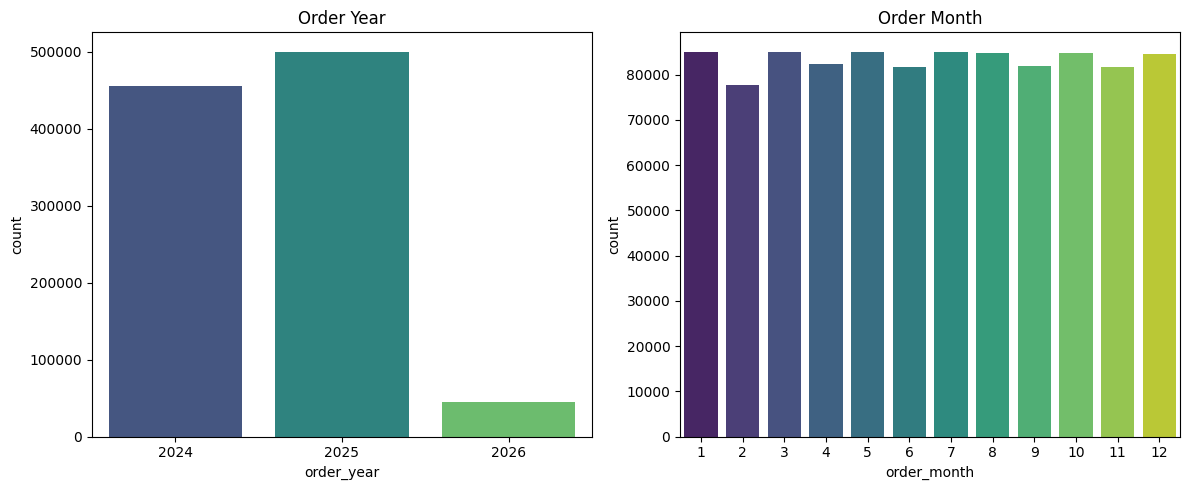

In [14]:
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
sns.countplot(x='order_year', data=df, palette='viridis')
plt.title('Order Year')

plt.subplot(1, 2, 2)
sns.countplot(x='order_month', data=df, palette='viridis')
plt.title('Order Month')

plt.tight_layout()
plt.show()

**🗓️ Weekend vs Weekday Orders**

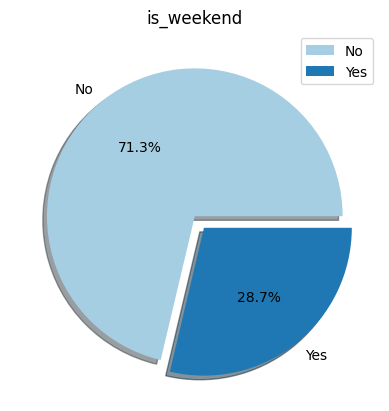

In [15]:
plt.pie(x=df["is_weekend"].value_counts(), labels=df["is_weekend"].value_counts().index, colors = ["#A6CEE3", "#1F78B4"], autopct="%0.1f%%", explode=[0, 0.1], shadow=True, radius=1)
plt.legend()
plt.title('is_weekend')
plt.show()

**📦 Order Status**

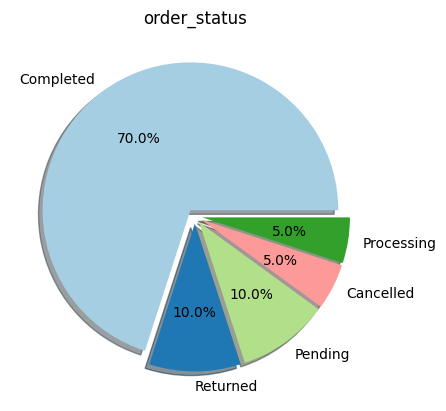

In [16]:
counts = df["order_status"].value_counts()

plt.pie(
    x=counts,
    labels=counts.index,
    colors=["#A6CEE3", "#1F78B4", "#B2DF8A", "#FB9A99", "#33A02C"], 
    autopct="%0.1f%%",
    explode=[0.05]*5,  
    shadow=True
)

plt.title('order_status')
plt.show()

**👤 Top 5 Customers**

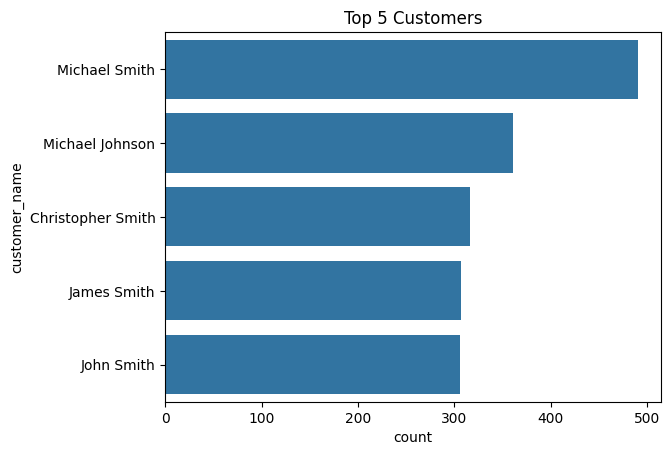

In [17]:
top_customers = df["customer_name"].value_counts().head(5).reset_index()
top_customers.columns = ["customer_name", "count"]
sns.barplot(x=top_customers["count"], y=top_customers["customer_name"])
plt.title("Top 5 Customers")
plt.show()

**🚻 Gender Distribution**

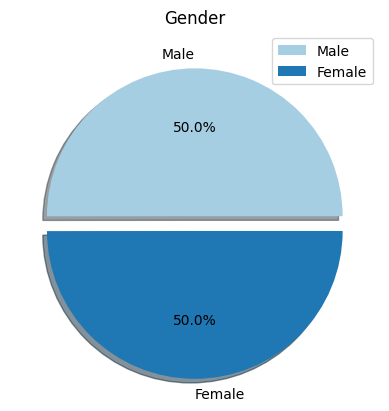

In [18]:
plt.pie(x=df["gender"].value_counts(), labels=df["gender"].value_counts().index, colors = ["#A6CEE3", "#1F78B4"], autopct="%0.1f%%", explode=[0, 0.1], shadow=True, radius=1)
plt.legend()
plt.title('Gender')
plt.show()

**🎂 Age Analysis**

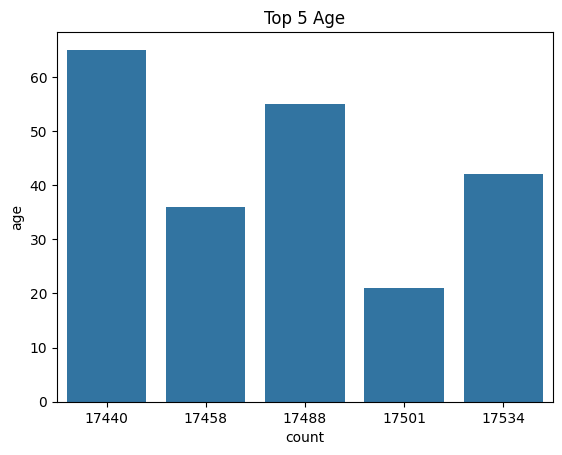

In [19]:
top_age = df["age"].value_counts().head(5).reset_index()
top_age.columns = ["age", "count"]
sns.barplot(x=top_age["count"], y=top_age["age"])
plt.title("Top 5 Age")
plt.show()

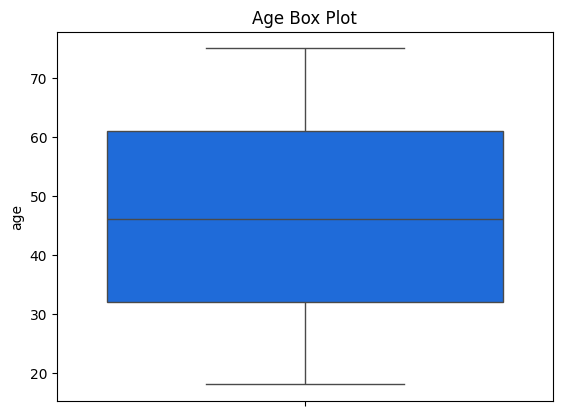

In [20]:
sns.boxplot(y=df["age"], color="#0065F8")
plt.title("Age Box Plot")
plt.show()

**🌍 Customers by Country**

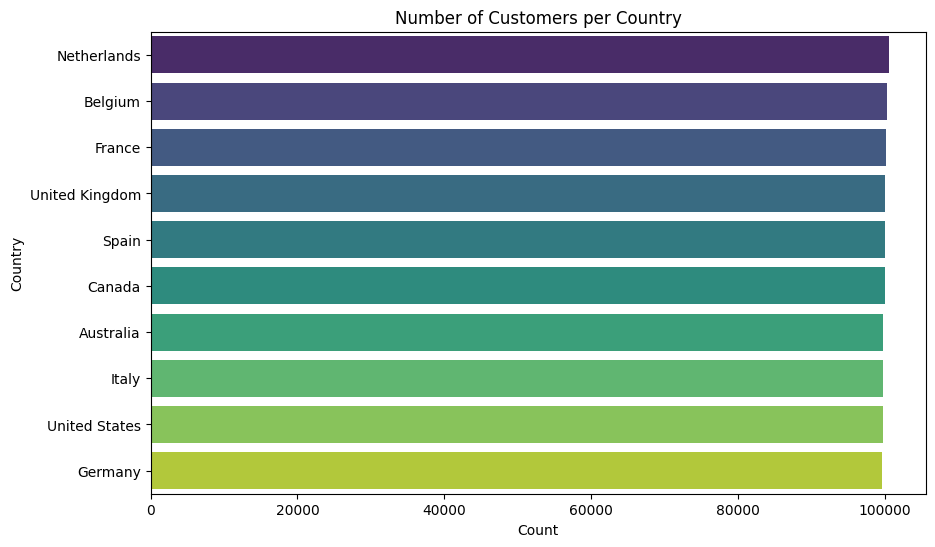

In [21]:
country_counts = df['country'].value_counts().reset_index()
country_counts.columns = ['country', 'count']

plt.figure(figsize=(10,6))
sns.barplot(x='count', y='country', data=country_counts, palette='viridis')
plt.title('Number of Customers per Country')
plt.xlabel('Count')
plt.ylabel('Country')
plt.show()

**🏙️ Top 5 Cities**

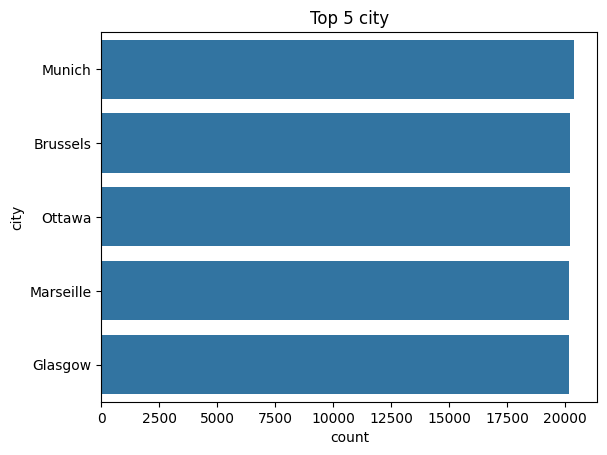

In [22]:
top_age = df["city"].value_counts().head(5).reset_index()
top_age.columns = ["city", "count"]
sns.barplot(x=top_age["count"], y=top_age["city"])
plt.title("Top 5 city")
plt.show()

**🛍️ Top 10 Products**

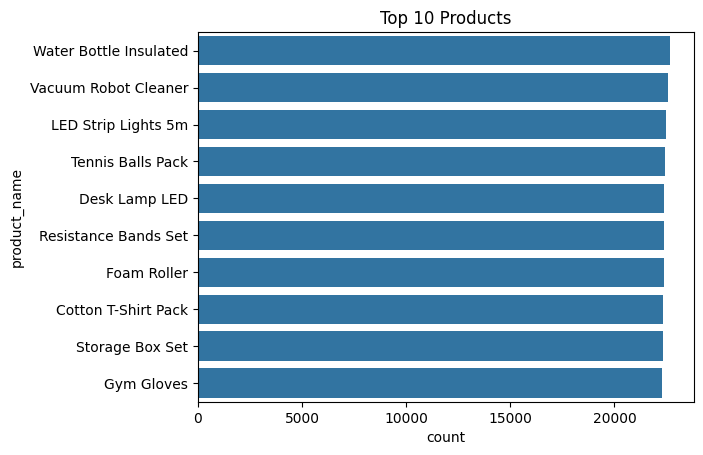

In [23]:
top_products = df["product_name"].value_counts().head(10).reset_index()
top_products.columns = ["product_name", "count"]
sns.barplot(x=top_products["count"], y=top_products["product_name"])
plt.title("Top 10 Products")
plt.show()

**🏷️ Brands & Categories**

In [24]:
table = df["brand"].value_counts().reset_index()
table.columns = ["brand", "count"]
print(table)

       brand  count
0       Dell  50436
1       Sony  50299
2    Philips  50293
3      GoPro  50293
4     Fitbit  50202
5     Xiaomi  50088
6     Huawei  50045
7      Anker  50004
8      Apple  49997
9        JBL  49976
10      Asus  49934
11      Nike  49919
12   Samsung  49914
13    Baseus  49879
14    Adidas  49862
15    Lenovo  49843
16        HP  49826
17     Nikon  49794
18     Canon  49761
19  Logitech  49758


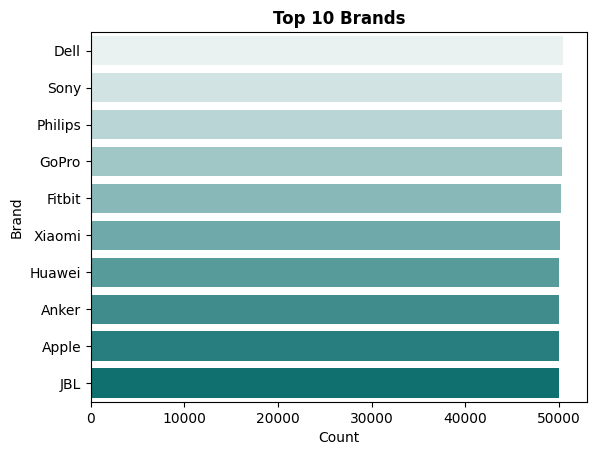

In [25]:
top_brands = df["brand"].value_counts().head(10).reset_index()
top_brands.columns = ["brand", "count"]
sns.barplot(
    x="count",
    y="brand",
    data=top_brands,
    palette=sns.color_palette("light:#008080", n_colors=len(top_brands))
)
plt.title("Top 10 Brands", fontweight="bold")
plt.xlabel("Count")
plt.ylabel("Brand")
plt.show()

In [26]:
table = df["category"].value_counts().reset_index()
table.columns = ["category", "count"]
print(table)

      category   count
0         Home  200589
1       Sports  200397
2  Electronics  200019
3       Health  199574
4     Clothing  199544


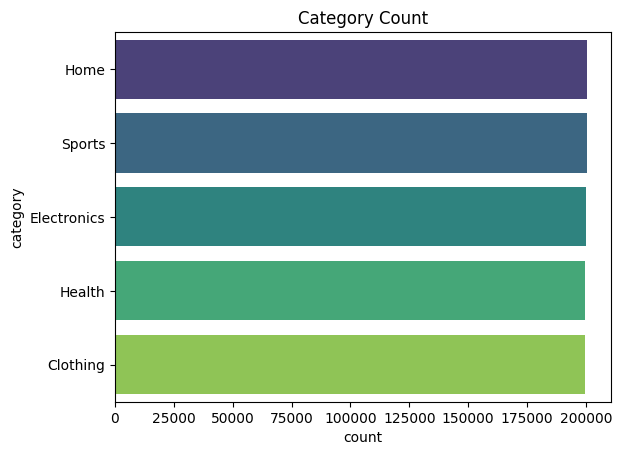

In [27]:
sns.countplot(y=df["category"], order=df["category"].value_counts().index, palette='viridis')
plt.title("Category Count")
plt.show()

**💳 Payment Methods**

In [28]:
table = df["payment_method"].value_counts().reset_index()
table.columns = ["payment_method", "count"]
print(table)

  payment_method   count
0     Debit Card  200805
1  Bank Transfer  200213
2         PayPal  199881
3      Apple Pay  199814
4    Credit Card  199410


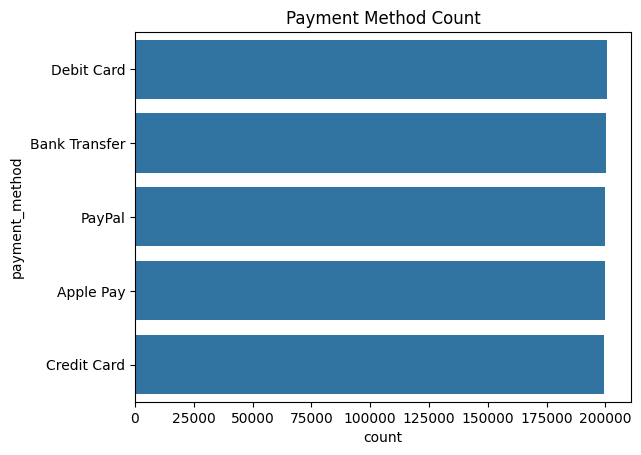

In [29]:
sns.countplot(y=df["payment_method"], order=df["payment_method"].value_counts().index)
plt.title("Payment Method Count")
plt.show()

In [30]:
failed = df[df["delivery_status"] == "Failed"]
print(f"Total Failed Deliveries: {len(failed)}")

Total Failed Deliveries: 49994


In [31]:
top_cities = failed["city"].value_counts().head(15).reset_index()
top_cities.columns = ["city", "count"]
print(top_cities)

           city  count
0       Calgary   1063
1     Barcelona   1050
2         Liege   1044
3         Perth   1043
4     Melbourne   1035
5        Bilbao   1035
6     Marseille   1032
7        Madrid   1031
8        Munich   1029
9   Los Angeles   1027
10     Brisbane   1026
11      Antwerp   1025
12   Manchester   1025
13       London   1024
14    Amsterdam   1024


**❌ Failed Deliveries**

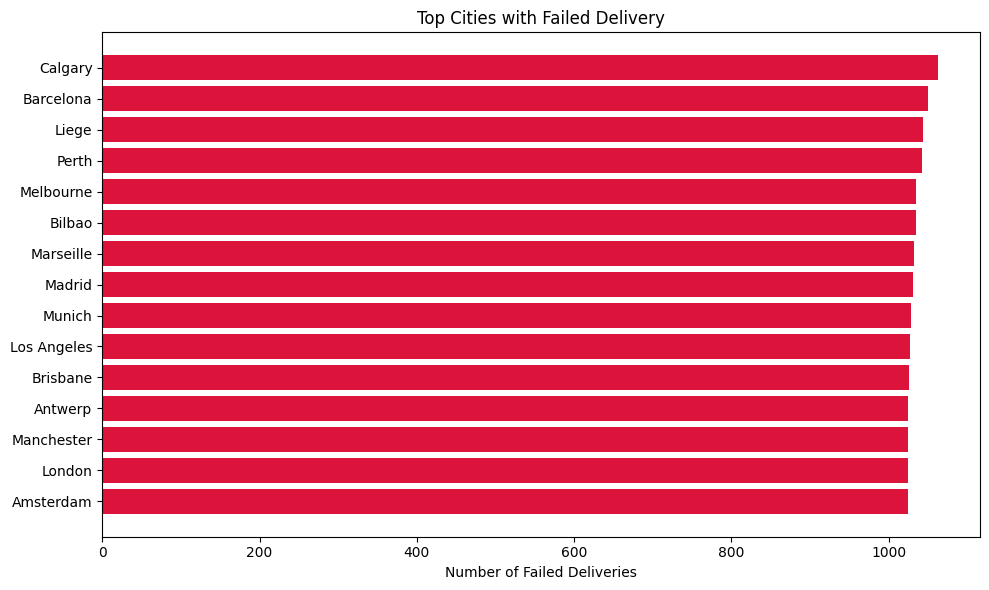

In [32]:
plt.figure(figsize=(10, 6))
plt.barh(top_cities["city"], top_cities["count"], color="crimson")
plt.title("Top Cities with Failed Delivery")
plt.xlabel("Number of Failed Deliveries")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [33]:
fig = px.bar(top_cities, x="count", y="city", orientation="h",
             color="count", color_continuous_scale="Reds",
             title="Top Cities with Failed Delivery",
             text="count")
fig.update_traces(textposition="outside")
fig.update_layout(yaxis=dict(autorange="reversed"), coloraxis_showscale=False)
fig.show(renderer="iframe")

**🏆 Strongest City per Category (Most Buying)**

In [34]:
city_cat = df.groupby(["city", "category"]).size().reset_index()
city_cat.columns = ["city", "category", "count"]
city_cat = city_cat.sort_values("count", ascending=False).head(20)

print(city_cat)

           city     category  count
175      Ottawa     Clothing   4186
155      Munich     Clothing   4145
14      Antwerp       Sports   4141
216   The Hague  Electronics   4138
157      Munich       Health   4132
239     Utrecht       Sports   4127
133  Manchester         Home   4120
49     Brussels       Sports   4113
148       Milan         Home   4111
105       Liege     Clothing   4109
113      London         Home   4103
159      Munich       Sports   4102
123        Lyon         Home   4102
69    Eindhoven       Sports   4101
46     Brussels  Electronics   4096
24       Berlin       Sports   4089
231       Turin  Electronics   4089
191     Phoenix  Electronics   4087
200   Rotterdam     Clothing   4084
82        Ghent       Health   4081


In [35]:
fig = px.bar(city_cat, x="count", y="city", color="category",
             orientation="h", barmode="group",
             title="Most Buying: City x Category", text="count")
fig.update_layout(yaxis=dict(autorange="reversed"))
fig.show()
 
fig = px.treemap(city_cat, path=["city", "category"],
                 values="count", color="count",
                 color_continuous_scale="Blues",
                 title="Most Buying Treemap: City -> Category")
fig.show()

**🗺️ City + Country Failed Delivery**

In [36]:
failed = df[df["delivery_status"] == "Failed"]
 
city_country = failed.groupby(["country", "city"]).size().reset_index()
city_country.columns = ["country", "city", "count"]
city_country = city_country.sort_values("count", ascending=False).head(15)
city_country["city_country"] = city_country["city"] + " (" + city_country["country"] + ")"
print(city_country)

           country         city  count                 city_country
10          Canada      Calgary   1063             Calgary (Canada)
35           Spain    Barcelona   1050            Barcelona (Spain)
9          Belgium        Liege   1044              Liege (Belgium)
3        Australia        Perth   1043            Perth (Australia)
36           Spain       Bilbao   1035               Bilbao (Spain)
2        Australia    Melbourne   1035        Melbourne (Australia)
16          France    Marseille   1032           Marseille (France)
37           Spain       Madrid   1031               Madrid (Spain)
24         Germany       Munich   1029             Munich (Germany)
47   United States  Los Angeles   1027  Los Angeles (United States)
1        Australia     Brisbane   1026         Brisbane (Australia)
5          Belgium      Antwerp   1025            Antwerp (Belgium)
44  United Kingdom   Manchester   1025  Manchester (United Kingdom)
43  United Kingdom       London   1024      Lond

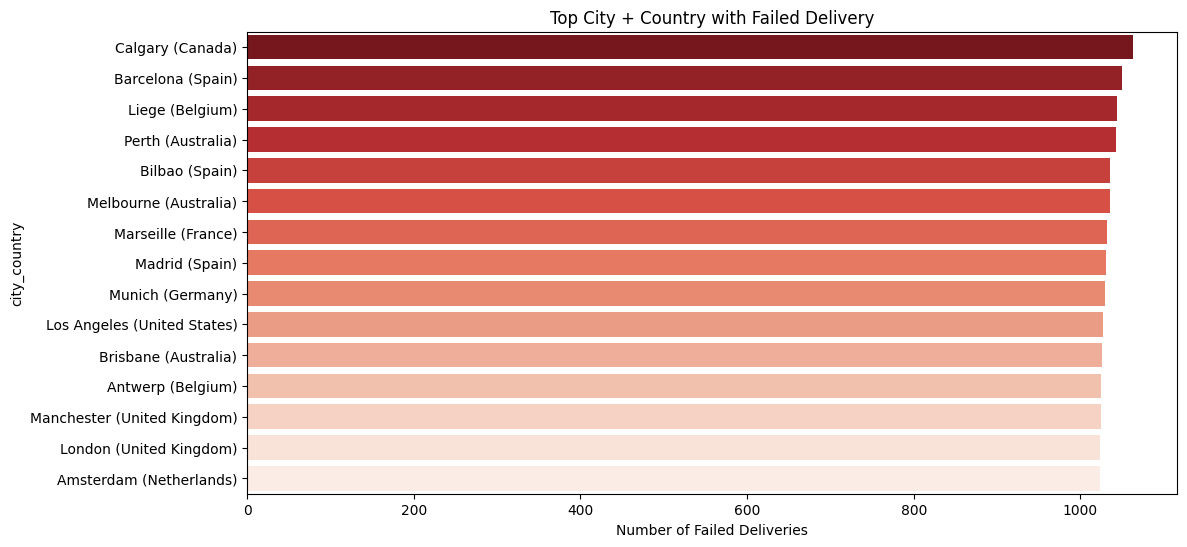

In [37]:
plt.figure(figsize=(12, 6))
sns.barplot(data=city_country, x="count", y="city_country", palette="Reds_r")
plt.title("Top City + Country with Failed Delivery")
plt.xlabel("Number of Failed Deliveries")
plt.show()
 
fig = px.treemap(city_country, path=["country", "city"],
                 values="count", color="count",
                 color_continuous_scale="Reds",
                 title="Failed Deliveries: Country -> City (Treemap)")
fig.show()
 

**🔥 Correlation Heatmap**

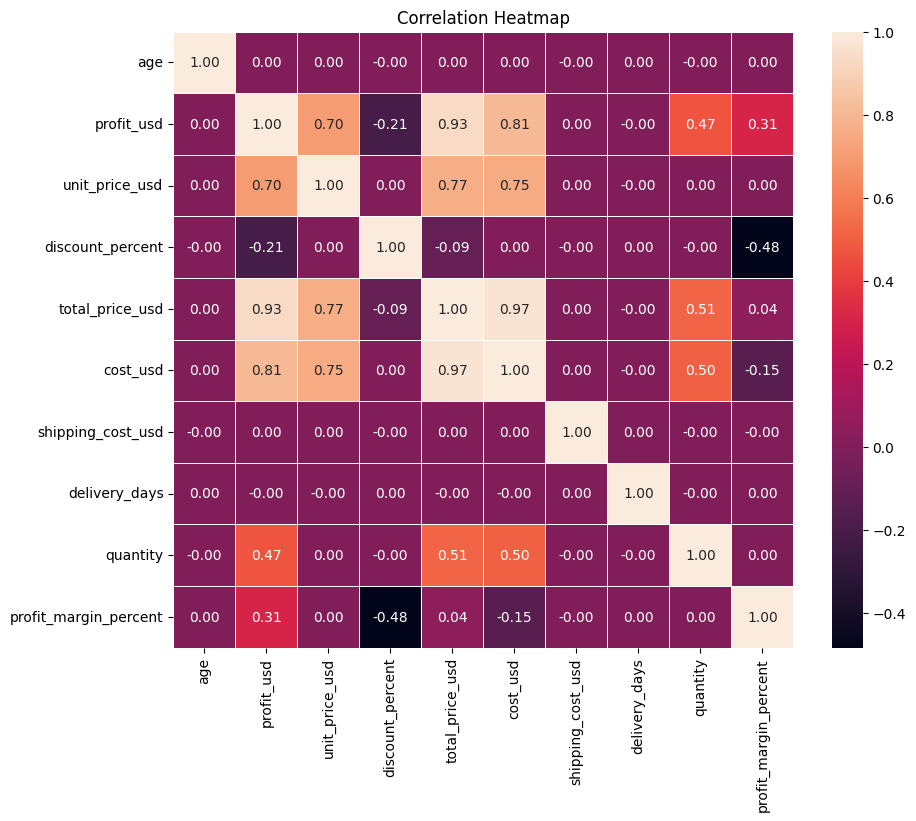

In [38]:
corr = df[["age", "profit_usd", "unit_price_usd", "discount_percent",
           "total_price_usd", "cost_usd", "shipping_cost_usd",
           "delivery_days", "quantity", "profit_margin_percent"]].corr()
 
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

**💰 Mean Profit by Category**

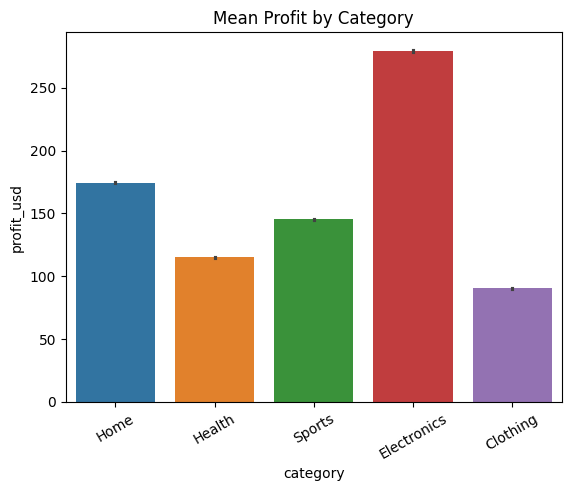

In [39]:
sns.barplot(data=df, x="category", y="profit_usd", estimator="mean", palette="tab10")
plt.title("Mean Profit by Category")
plt.xticks(rotation=30)
plt.show()

**💰 Mean Profit by Gender**

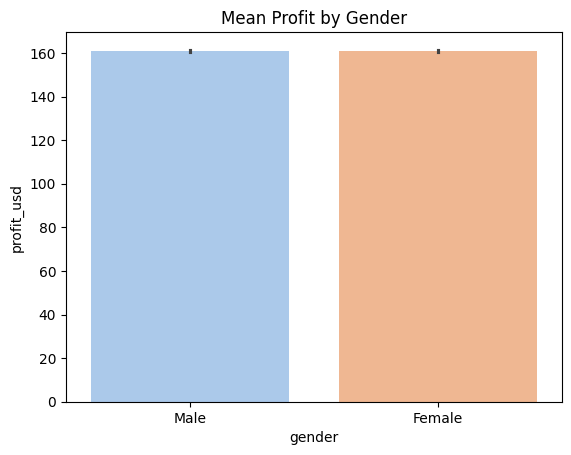

In [40]:
sns.barplot(data=df, x="gender", y="profit_usd", estimator="mean", palette="pastel")
plt.title("Mean Profit by Gender")
plt.show()

**🔵 Scatter: Unit Price vs Profit**

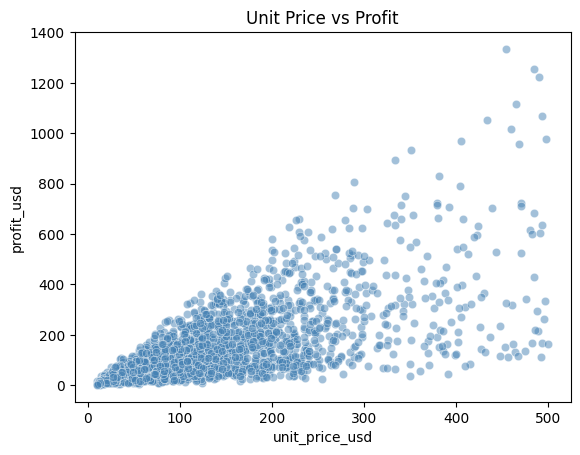

In [41]:
sample = df.sample(2000, random_state=42)
sns.scatterplot(data=sample, x="unit_price_usd", y="profit_usd", alpha=0.5, color="steelblue")
plt.title("Unit Price vs Profit")
plt.show()

**✈️Shipping Method**

In [42]:
table = df["shipping_method"].value_counts().reset_index()
table.columns = ["shipping_method", "count"]
print(table)

  shipping_method   count
0        Next Day  250500
1        Standard  250261
2         Economy  249777
3         Express  249585


In [43]:
Q1 = df['profit_usd'].quantile(0.25)
Q3 = df['profit_usd'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['profit_usd'] < lower_bound) | (df['profit_usd'] > upper_bound)]

print(f"Total outliers found: {len(outliers)}")
print("Firs 10 Values: ")
print(outliers[['shipping_method', 'profit_usd']].head(10))

print("\nAverage profit of outliers by shipping method:")
print(outliers.groupby('shipping_method')['profit_usd'].mean())

Total outliers found: 56873
Firs 10 Values: 
    shipping_method  profit_usd
2           Economy      468.45
52          Economy      636.15
54         Standard      848.24
80          Economy     1022.65
102         Economy      506.83
114        Next Day      804.01
118         Express      569.13
119        Standard      938.37
136         Economy      557.72
137         Economy      690.92

Average profit of outliers by shipping method:
shipping_method
Economy     642.239420
Express     643.145844
Next Day    642.401240
Standard    638.996233
Name: profit_usd, dtype: float64


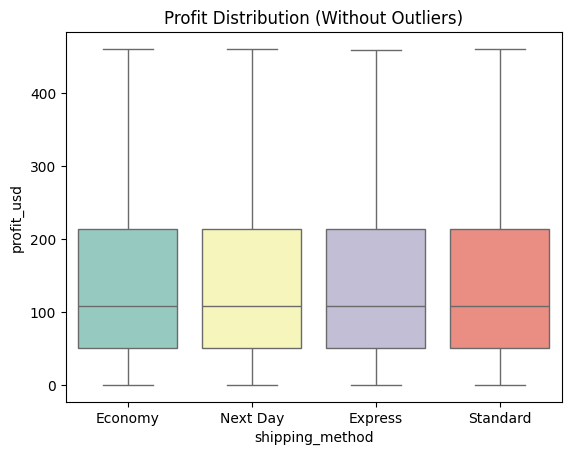

In [44]:
sns.boxplot(data=df, x="shipping_method", y="profit_usd", palette="Set3", showfliers=False)
plt.title("Profit Distribution (Without Outliers)")
plt.show()

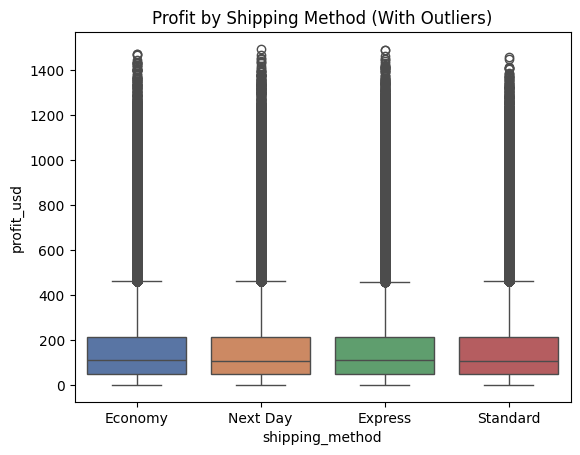

In [45]:
sns.boxplot(data=df, x="shipping_method", y="profit_usd", palette="deep")
plt.title("Profit by Shipping Method (With Outliers)")
plt.show()

**🔵 Scatter: Discount % vs Profit**

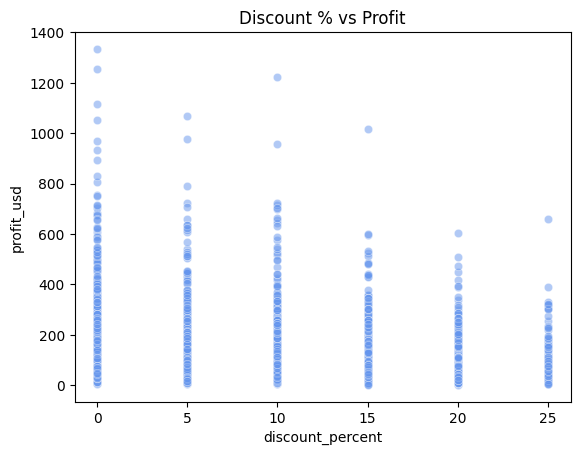

In [46]:
sns.scatterplot(
    data=sample,
    x="discount_percent",
    y="profit_usd",
    alpha=0.5,
    color="cornflowerblue"
)

plt.title("Discount % vs Profit")
plt.show()

In [47]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["year_month"] = df["order_date"].dt.to_period("M").astype(str)
monthly = df.groupby("year_month")["total_price_usd"].sum().reset_index()
monthly.columns = ["year_month", "revenue"]

target_month = "2025-01"
january_revenue = monthly[monthly['year_month'] == target_month]['revenue'].values[0]
print(f"Total Revenue for {target_month}: ${january_revenue:,.2f}")

Total Revenue for 2025-01: $17,173,772.94


**While individual orders are in the Thousands (K), the volume of transactions per month scales the total revenue into the Millions (M).**

**📅 Monthly Revenue Trend**

In [48]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["year_month"] = df["order_date"].dt.to_period("M").astype(str)
monthly = df.groupby("year_month")["total_price_usd"].sum().reset_index()
monthly.columns = ["year_month", "revenue"]
fig = px.line(monthly, x="year_month", y="revenue",title="Monthly Revenue Trend", markers=True)
fig.show()

**🔵 Scatter: Age vs Total Price**

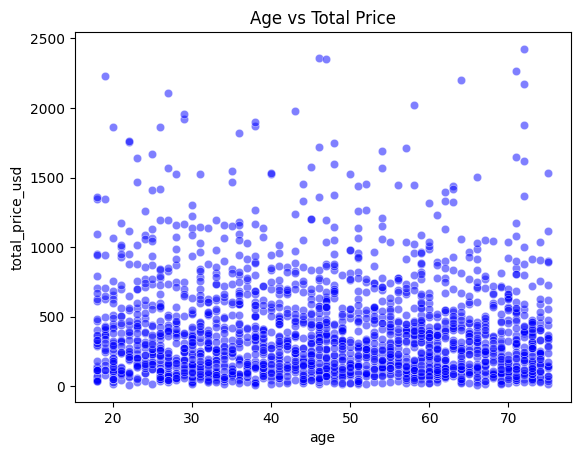

In [49]:
sns.scatterplot(data=sample, x="age", y="total_price_usd", alpha=0.5, color="blue")
plt.title("Age vs Total Price")
plt.show()

In [50]:
cat_profit = df.groupby("category")["profit_usd"].mean().reset_index()
cat_profit.columns = ["category", "mean_profit"]
fig = px.bar(cat_profit, x="category", y="mean_profit",
             title="Mean Profit by Category", color="mean_profit",color_continuous_scale="bluyl")
fig.show()

**📊 Category x Delivery Status**

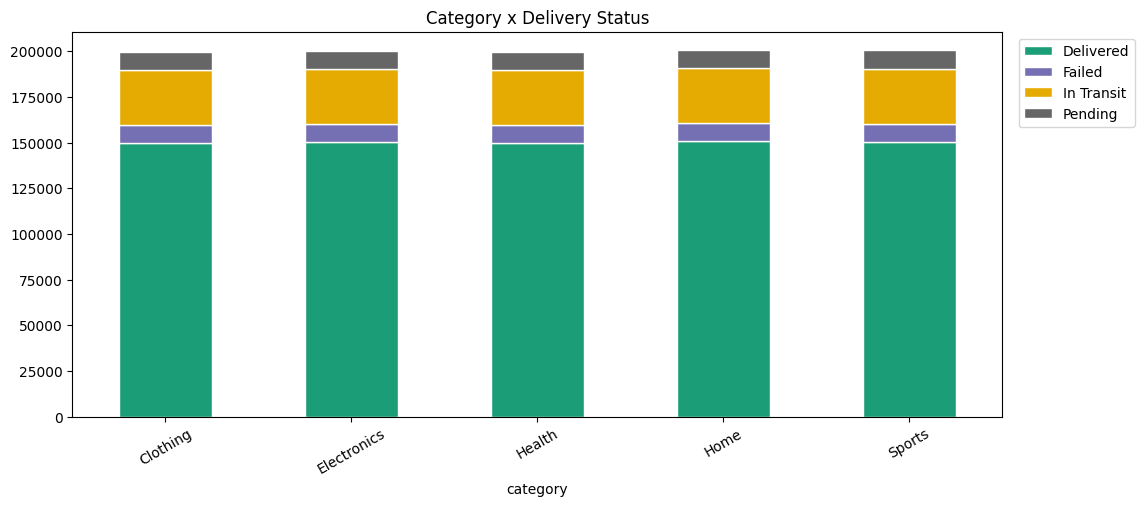

In [51]:
stacked = df.groupby(["category", "delivery_status"]).size().unstack(fill_value=0)
stacked.plot(kind="bar", stacked=True, colormap="Dark2", figsize=(12, 5), edgecolor="white")
plt.title("Category x Delivery Status")
plt.xticks(rotation=30)
plt.legend(bbox_to_anchor=(1.01, 1))
plt.show()
 